# Lab Day 1 — 2A202602625

Notebook hoàn thiện Part 0–4. Mở **bản này** và chọn GPU trên Colab/Kaggle.
Đọc `CLOUD_RUN_GUIDE.md` kèm gói. Mặc định cloud chạy `full`, máy local chạy `smoke`.
Full: baseline 20 epoch, 3 seed, menu 7 chủ đề, chọn bằng val, chấm eval cuối.
Smoke chỉ kiểm tra pipeline trên mẫu nhỏ, không dùng để nộp hoặc kết luận.

Đặt `RUN_GROUPS` ở ô cấu hình nếu muốn chạy ít chủ đề hơn; giữ cùng lựa chọn
qua các lần khôi phục. Cache/checkpoint sẽ tái dùng cùng code/cấu hình/dữ liệu.
Sau khi đã chốt `selection.json`, không thay cấu hình dựa vào điểm eval.


In [2]:
# ===== Bootstrap: upload gói local đã cập nhật, không cần git push =====
import os, sys, shutil, zipfile, subprocess, importlib.util
from pathlib import Path

BUNDLE_PATH = ""  # Kaggle: điền đường dẫn ZIP hoặc folder dataset nếu tự phát hiện không được
USE_DRIVE = True  # Colab: lưu artifact/checkpoint vào Drive để khôi phục sau mất runtime
RUN_GROUPS = None # None = cả 7; ví dụ ["optimizer", "dropout", "amp", "init"]
STUDENT_NAME = "Nguyễn Đức Anh" # điền họ tên trước khi tạo REPORT.md
IS_COLAB = importlib.util.find_spec("google.colab") is not None if importlib.util.find_spec("google") else False
IS_KAGGLE = Path("/kaggle/working").exists()
IS_CLOUD = IS_COLAB or IS_KAGGLE
MODE = "full" if IS_CLOUD else "smoke" # có thể đổi thành smoke để kiểm tra nhanh trên cloud

workspace = Path("/content/k4_lab") if IS_COLAB else Path("/kaggle/working/k4_lab") if IS_KAGGLE else None
repo = None
if workspace and (workspace / "data/covtype.csv.gz").exists():
    repo = workspace
elif not IS_CLOUD:
    for candidate in [Path.cwd(), *Path.cwd().parents]:
        if (candidate / "data/covtype.csv.gz").exists():
            repo = candidate
            break
if repo is None:
    source = Path(BUNDLE_PATH) if BUNDLE_PATH else None
    if IS_COLAB and source is None:
        from google.colab import files
        uploaded = files.upload() # chọn cloud_bundle_2A202602625.zip
        names = [name for name in uploaded if name.endswith(".zip")]
        if len(names) != 1:
            raise ValueError("Hãy upload đúng một cloud_bundle ZIP")
        source = Path(names[0])
    elif IS_KAGGLE and source is None:
        zips = list(Path("/kaggle/input").rglob("cloud_bundle_2A202602625.zip"))
        if zips:
            source = zips[0]
        else:
            data_files = list(Path("/kaggle/input").rglob("covtype.csv.gz"))
            if data_files:
                source = data_files[0].parent.parent # Kaggle có thể đã giải nén dataset
    if source is None or not source.exists():
        raise FileNotFoundError("Không tìm thấy gói. Đặt BUNDLE_PATH tới ZIP/folder dataset đã upload")
    workspace.mkdir(parents=True, exist_ok=True)
    if source.is_file():
        with zipfile.ZipFile(source) as archive:
            for item in archive.infolist():
                dest = (workspace / item.filename).resolve()
                if not dest.is_relative_to(workspace.resolve()):
                    raise ValueError("ZIP có đường dẫn không hợp lệ")
            archive.extractall(workspace)
    else:
        shutil.copytree(source, workspace, dirs_exist_ok=True)
    repo = workspace

REPO_ROOT = str(repo.resolve())
CODE_DIR = repo / "submission_2A202602625/code"
if not (CODE_DIR / "experiments.py").exists():
    raise FileNotFoundError("Gói chứa code cũ; hãy upload cloud_bundle mới được cung cấp")
if IS_COLAB and USE_DRIVE:
    from google.colab import drive
    drive.mount("/content/drive")
    OUTPUT_ROOT = Path("/content/drive/MyDrive/K4_Track4_Day1/submission_2A202602625")
else:
    OUTPUT_ROOT = repo / "submission_2A202602625"
OUT_DIR = str(OUTPUT_ROOT / "_smoke" if MODE == "smoke" else OUTPUT_ROOT)
Path(OUT_DIR).mkdir(parents=True, exist_ok=True)
if Path(OUT_DIR) / "code" != CODE_DIR:
    shutil.copytree(CODE_DIR, Path(OUT_DIR) / "code", dirs_exist_ok=True)
os.chdir(CODE_DIR)
sys.path.insert(0, str(CODE_DIR))
# Cloud có PyTorch CUDA sẵn: chỉ cài thư viện phụ đang thiếu, không thay torch.
missing = [pkg for module, pkg in [("numpy","numpy"), ("sklearn","scikit-learn"),
    ("pandas","pandas"), ("matplotlib","matplotlib"), ("openpyxl","openpyxl"),
    ("nbformat","nbformat")] if importlib.util.find_spec(module) is None]
if missing:
    subprocess.run([sys.executable, "-m", "pip", "install", *missing], check=True)
print("REPO_ROOT:", REPO_ROOT, "\nOUT_DIR:", OUT_DIR, "\nMODE:", MODE)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
REPO_ROOT: /content/k4_lab 
OUT_DIR: /content/drive/MyDrive/K4_Track4_Day1/submission_2A202602625 
MODE: full


In [3]:
import json, time, numpy as np, torch
from data import prepare_data, iterate_batches
from model import MLP, EXPECTED_PARAMS, count_params, init_weights, activation_stats
from train import DEFAULT_CFG, set_seed, evaluate, predict, run_experiment, final_eval
from experiments import run_baselines, run_menu, choose_final
from results_table import load_results, to_row, write_xlsx, seed_statistics
from reporting import finish_submission, package_submission, describe_comparison

device = "cuda" if torch.cuda.is_available() else "cpu"
if MODE == "full" and device != "cuda":
    raise RuntimeError("Full cần GPU: bật accelerator rồi restart runtime; dùng MODE='smoke' để kiểm tra CPU")
if device == "cpu":
    torch.set_num_threads(min(4, os.cpu_count() or 1))
print(f"PyTorch {torch.__version__}; device={device}")
if device == "cuda":
    print("GPU:", torch.cuda.get_device_name(0), "BF16:", torch.cuda.is_bf16_supported())
for folder in ("figures", "results", "checkpoints"):
    Path(OUT_DIR, folder).mkdir(parents=True, exist_ok=True)
set_seed(42)


PyTorch 2.11.0+cu130; device=cuda
GPU: Tesla T4 BF16: True


## Part 0 — Dữ liệu
Chia sẵn bằng metadata: chạy `scripts/split_data.py` từ thư mục gốc repo (tạo `data/processed/train.npz`, `eval.npz`).
Sau đó tách validation từ train, chuẩn hoá bằng thống kê của phần train còn lại, đưa lên device.

Val dùng để chọn cấu hình và epoch, eval chỉ dành cho đánh giá cuối. Vì vậy mean/std chỉ được fit trên train sau khi tách val; fit trên val hoặc eval sẽ đưa thông tin của tập kiểm tra vào quá trình huấn luyện. Cùng một phép biến đổi được áp dụng cho cả ba tập, còn 44 cột nhị phân được giữ nguyên.

`iterate_batches` giữ lô cuối dù số mẫu nhỏ hơn `batch_size`, để mọi mẫu train đều được dùng trong mỗi epoch.

In [4]:
split_run = subprocess.run(
    [sys.executable, "scripts/split_data.py"], cwd=REPO_ROOT, check=True,
    capture_output=True, text=True, encoding="utf-8",
    env={**os.environ, "PYTHONIOENCODING": "utf-8"},
)
print(split_run.stdout)
data = prepare_data(device, val_fraction=0.2, seed=42, processed_dir=f"{REPO_ROOT}/data/processed")
assert (len(data["X_tr"]), len(data["X_val"]), len(data["X_eval"])) == (371847, 92962, 116203)
for split in ("tr", "val", "eval"):
    X, y = data[f"X_{split}"], data[f"y_{split}"]
    assert X.shape[1] == 54 and X.dtype == torch.float32 and y.dtype == torch.int64
    assert int(y.min()) >= 0 and int(y.max()) <= 6
train_numeric = data["X_tr"][:, :10].double()
mean_tr = train_numeric.mean(dim=0)
std_tr = train_numeric.std(dim=0, unbiased=False)
print("Train numeric means:", mean_tr.cpu().numpy())
print("Train numeric stds: ", std_tr.cpu().numpy())
assert torch.allclose(mean_tr, torch.zeros_like(mean_tr), atol=1e-5)
assert torch.allclose(std_tr, torch.ones_like(std_tr), atol=1e-5)
majority_class = int(torch.bincount(data["y_tr"], minlength=7).argmax())
majority_acc = (data["y_val"] == majority_class).float().mean().item()
print(f"Majority class {majority_class}; val accuracy = {majority_acc:.4f}")
with np.load(f"{REPO_ROOT}/data/processed/eval.npz") as raw_eval:
    assert np.array_equal(data["eval_row_id"], raw_eval["row_id"])
    assert np.array_equal(data["X_eval"][:, 10:].cpu().numpy(), raw_eval["X"][:, 10:])
print(f"eval_row_id: {len(data['eval_row_id'])} unique IDs; first five = {data['eval_row_id'][:5]}")
batch_size = 512
remainder = len(data["X_tr"]) % batch_size
tail_X, tail_y = data["X_tr"][-(batch_size + remainder):], data["y_tr"][-(batch_size + remainder):]
last_batch = list(iterate_batches(tail_X, tail_y, batch_size, shuffle=False))[-1]
assert len(last_batch[0]) == remainder
print(f"Lô cuối được giữ lại: {len(last_batch[0])} mẫu (batch_size={batch_size}).")

train: X (464809, 54) float32, y (464809,) int64, nhãn 0..6 -> data/processed/train.npz
eval : X (116203, 54) float32, y (116203,) int64, nhãn 0..6 -> data/processed/eval.npz

lớp   train(%)   eval(%)
  0    36.461    36.460
  1    48.760    48.760
  2     6.154     6.154
  3     0.473     0.472
  4     1.634     1.634
  5     2.989     2.989
  6     3.530     3.530

đoán luôn lớp đa số (lớp 1) cho accuracy trên eval = 0.4876

tr: X (371847, 54) torch.float32, y (371847,) torch.int64
val: X (92962, 54) torch.float32, y (92962,) torch.int64
eval: X (116203, 54) torch.float32, y (116203,) torch.int64
Lớp đa số từ train: 1; accuracy trên val: 0.4876
Train numeric means: [-6.73883753e-11 -1.46488192e-10 -3.42966406e-09  3.00766271e-10
 -1.53744727e-09 -1.02212679e-10 -1.56614732e-09 -1.91377376e-09
 -1.41332503e-09  6.88944764e-10]
Train numeric stds:  [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
Majority class 1; val accuracy = 0.4876
eval_row_id: 116203 unique IDs; first five = [10 11 12 23 34]
Lô cu

## Part 1 — Model và kiểm tra sức khoẻ
M-base: 54→256→128→7, He cho mọi Linear, bias=0, 47 879 tham số.
Đo bước 0 trên toàn bộ val trước cập nhật; model riêng ghi nhớ 20 mẫu.


M-base parameters: 47879
Input: (8, 54)
0 Linear: (8, 256)
1 ReLU: (8, 256)
2 Dropout: (8, 256)
3 Linear: (8, 128)
4 ReLU: (8, 128)
5 Dropout: (8, 128)
6 Linear: (8, 7)
Val CE bước 0 = 2.377572; ln 7 = 1.945910; độ lệch = +0.431662
Logit std bước 0 = 0.647230; std sau Linear = [0.6885976195335388, 0.654438853263855, 0.6494792699813843]
Gradient sau backward đầu tiên (trước cập nhật):
net.0.weight: 1.04126036
net.0.bias: 0.43265626
net.3.weight: 3.08758187
net.3.bias: 0.54031557
net.6.weight: 2.49990296
net.6.bias: 0.64980221
20 mẫu, 500 bước: loss 2.345478 -> 0.00000075; accuracy = 100.00%


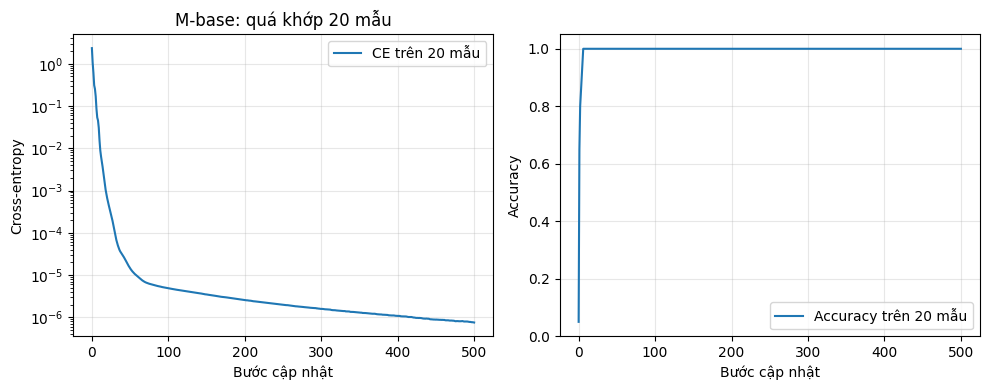

In [5]:
import math
import random
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

# Seed cố định; không phụ thuộc set_seed còn là TODO ở Part 2.
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)
model = MLP(hidden=(256, 128), dropout=0.0, init="he").to(device)
assert count_params(model) == 47_879
print("M-base parameters:", count_params(model))
linears = [layer for layer in model.net if isinstance(layer, nn.Linear)]
assert [(l.in_features, l.out_features) for l in linears] == [(54, 256), (256, 128), (128, 7)]
assert all(l.bias is not None and torch.count_nonzero(l.bias) == 0 for l in linears)
model.eval()
with torch.no_grad():
    h = torch.randn(8, 54, device=device)
    print("Input:", tuple(h.shape))
    for name, layer in model.net.named_children():
        h = layer(h)
        print(f"{name} {type(layer).__name__}: {tuple(h.shape)}")
    assert h.shape == (8, 7)

# Toàn bộ val, trước bất kỳ optimizer.step nào; trung bình có trọng số theo số mẫu.
with torch.no_grad():
    loss_sum = 0.0
    logit_sum_sq = 0.0
    logit_sum = 0.0
    for xb, yb in iterate_batches(data["X_val"], data["y_val"], 4096, shuffle=False):
        logits = model(xb)
        loss_sum += F.cross_entropy(logits, yb, reduction="sum").item()
        logit_sum += logits.double().sum().item()
        logit_sum_sq += logits.double().square().sum().item()
    loss_step0 = loss_sum / len(data["y_val"])
    n_logits = len(data["y_val"]) * 7
    logit_std = math.sqrt(logit_sum_sq / n_logits - (logit_sum / n_logits)**2)
reference = math.log(7)
print(f"Val CE bước 0 = {loss_step0:.6f}; ln 7 = {reference:.6f}; độ lệch = {loss_step0-reference:+.6f}")
print(f"Logit std bước 0 = {logit_std:.6f}; std sau Linear = {activation_stats(model, data['X_val'][:4096])}")

# Model riêng: thử khả năng ghi nhớ 20 mẫu, không dùng để đánh giá tổng quát hoá.
torch.manual_seed(42)
tiny_model = MLP(hidden=(256, 128), dropout=0.0, init="he").to(device)
assert count_params(tiny_model) == 47_879
xb, yb = data["X_tr"][:20], data["y_tr"][:20]
assert yb.dtype == torch.int64 and int(yb.min()) >= 0 and int(yb.max()) <= 6
optimizer = torch.optim.Adam(tiny_model.parameters(), lr=0.01)
tiny_model.train()
loss_history, acc_history = [], []
gradient_norms = {}
for step in range(501):
    optimizer.zero_grad(set_to_none=True)
    logits = tiny_model(xb)
    loss = F.cross_entropy(logits, yb)
    assert torch.isfinite(loss)
    loss_history.append(loss.item())
    acc_history.append((logits.argmax(1) == yb).float().mean().item())
    if step == 500:
        break
    loss.backward()
    if step == 0:
        print("Gradient sau backward đầu tiên (trước cập nhật):")
        for name, parameter in tiny_model.named_parameters():
            assert parameter.grad is not None
            norm = parameter.grad.norm().item()
            assert math.isfinite(norm) and norm > 0, name
            gradient_norms[name] = norm
            print(f"{name}: {norm:.8f}")
    optimizer.step()
print(f"20 mẫu, 500 bước: loss {loss_history[0]:.6f} -> {loss_history[-1]:.8f}; accuracy = {acc_history[-1]:.2%}")
assert loss_history[-1] < 0.01 and acc_history[-1] == 1.0
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].semilogy(range(501), loss_history, label="CE trên 20 mẫu")
axes[0].set(xlabel="Bước cập nhật", ylabel="Cross-entropy", title="M-base: quá khớp 20 mẫu")
axes[1].plot(range(501), acc_history, label="Accuracy trên 20 mẫu")
axes[1].set(xlabel="Bước cập nhật", ylabel="Accuracy", ylim=(0, 1.05))
for ax in axes:
    ax.legend()
    ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(f"{OUT_DIR}/figures/part1_overfit20.png", dpi=150)
plt.show()
part1_result = dict(seed=42, parameters=count_params(model), loss_step0=loss_step0,
                    ln7=reference, logit_std=logit_std, gradient_norms=gradient_norms,
                    steps=500, optimizer="Adam", lr=0.01, loss=loss_history, accuracy=acc_history)
with open(f"{OUT_DIR}/results/part1_health.json", "w", encoding="utf-8") as f:
    json.dump(part1_result, f, ensure_ascii=False, indent=2)


In [6]:
from IPython.display import display, Markdown
display(Markdown(f"**Nhận xét Part 1:** CE val bước 0 = {loss_step0:.6f}; ln7 = {reference:.6f}; "
    f"lệch {loss_step0-reference:+.6f}. Logits std={logit_std:.6f}; He sinh logits chưa đều nên CE "
    "không nhất thiết bằng ln7. Chuẩn hoá đã kiểm tra trên train; giữ đúng He, không ép loss về mốc. "
    f"20 mẫu sau 500 bước: loss={loss_history[-1]:.8f}, accuracy={acc_history[-1]:.0%}. "
    "Cả sáu gradient khác None/0. Phép thử này chưa chứng minh tổng quát hoá."))


**Nhận xét Part 1:** CE val bước 0 = 2.377572; ln7 = 1.945910; lệch +0.431662. Logits std=0.647230; He sinh logits chưa đều nên CE không nhất thiết bằng ln7. Chuẩn hoá đã kiểm tra trên train; giữ đúng He, không ép loss về mốc. 20 mẫu sau 500 bước: loss=0.00000075, accuracy=100%. Cả sáu gradient khác None/0. Phép thử này chưa chứng minh tổng quát hoá.

## Part 2 — Pipeline, chọn lr baseline và nhiễu seed
Dự đoán trước: SGDM lr nhỏ có thể học chậm; lr lớn có thể xuống nhanh hoặc dao động.
Tune lr {0.01, 0.03, 0.1} trong 3 epoch bằng val, sau đó chạy baseline 20 epoch
với seed 1, 2, 3. Train loss đo trên 50k mẫu cố định ở eval, val toàn bộ.
Mỗi epoch lưu JSON, PNG và checkpoint; chạy lại sẽ tiếp tục từ epoch hoàn tất.



Dự đoán trước tune-sgdm-lr0.01: lr quá thấp có thể học chậm; lr cao hơn có thể cải thiện nhanh hoặc dao động.
tune-sgdm-lr0.01 1/3: train=0.5819 val=0.5804 acc=0.7560 F1=0.4936 1.6s
tune-sgdm-lr0.01 2/3: train=0.5301 val=0.5294 acc=0.7758 F1=0.5831 1.3s
tune-sgdm-lr0.01 3/3: train=0.4953 val=0.4947 acc=0.7906 F1=0.5982 1.3s
Kết quả: {'status': 'complete', 'step0_loss': 2.2690618110553, 'best_val_loss': 0.49466621525811183, 'best_epoch': 3, 'final_train_loss': 0.4952737494468689, 'final_val_loss': 0.49466621525811183, 'val_acc': 0.7906348830705019, 'val_macro_f1': 0.5982364118210796, 'time_per_epoch_s': 1.4019007066666898, 'peak_mem_MB': 202.6943359375, 'diverged': False, 'clip_fraction': 0.0, 'skipped_updates': 0}

Dự đoán trước tune-sgdm-lr0.03: lr quá thấp có thể học chậm; lr cao hơn có thể cải thiện nhanh hoặc dao động.
tune-sgdm-lr0.03 1/3: train=0.5195 val=0.5170 acc=0.7801 F1=0.5788 1.4s
tune-sgdm-lr0.03 2/3: train=0.4568 val=0.4572 acc=0.8069 F1=0.6547 1.3s
tune-sgdm-lr0.03 3/3

**Đối chiếu baseline:** `base-s1`: best epoch 18, val F1=0.8410, accuracy=0.9069, ΔF1 so base-s1=+0.0000. |Δ| không vượt 2σ=0.0238; đây là mốc tham khảo nhiễu baseline, chưa là kiểm định thống kê của cấu hình mới. Đọc hình compare_baseline để nhận xét còn giảm hay quá khớp; không dùng smoke để kết luận.

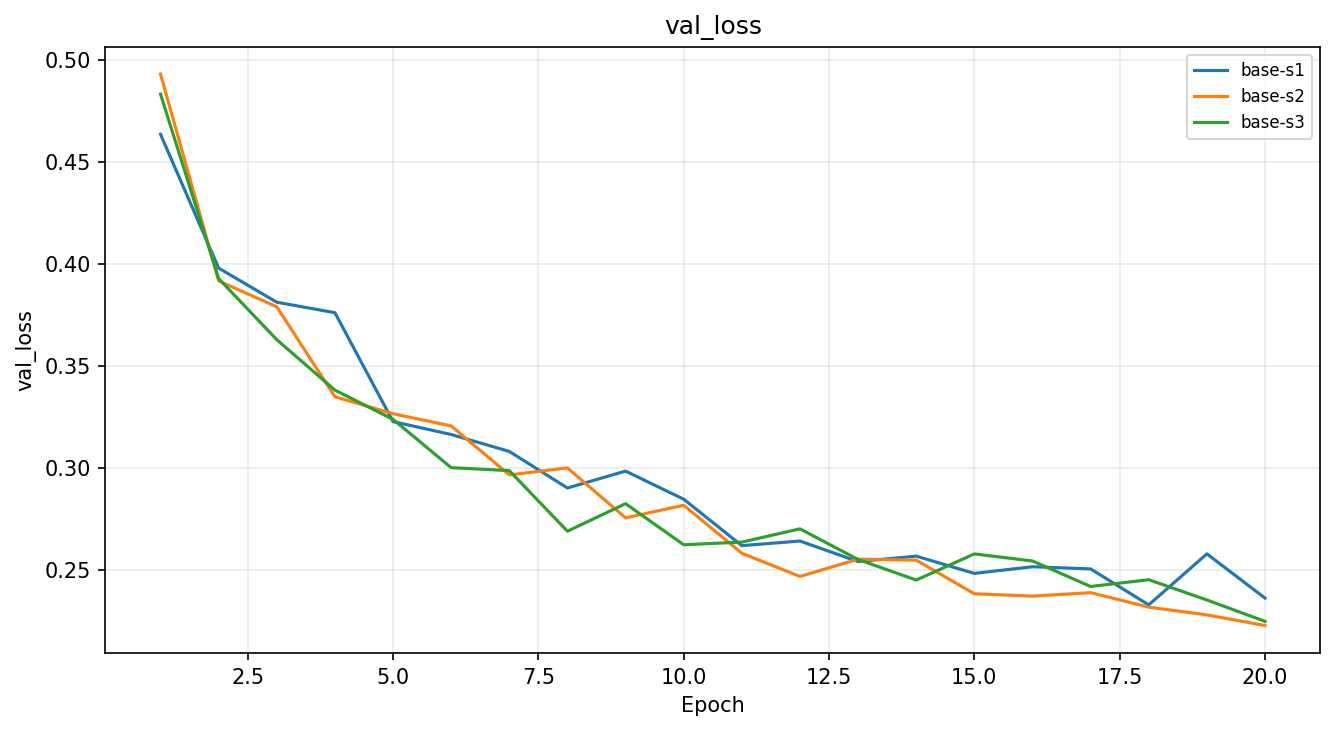

In [7]:
# Smoke tách riêng sau khi Part 0/1 đã kiểm tra dữ liệu đầy đủ.
if MODE == "smoke":
    data = {**data, "X_tr": data["X_tr"][:1024], "y_tr": data["y_tr"][:1024],
            "X_val": data["X_val"][:512], "y_val": data["y_val"][:512],
            "signature": data["signature"] + ":smoke1024-val512"}
base_cfg, baseline_results = run_baselines(data, OUT_DIR,
    epochs=20 if MODE == "full" else 2, tune_epochs=3 if MODE == "full" else 1)
stats = seed_statistics(baseline_results)
print(json.dumps(stats, indent=2))
base_result = next(r for r in baseline_results if r["cfg"]["exp_id"] == "base-s1")
print("Best epoch:", base_result["summary"]["best_epoch"])
print("Val-loss curve:", base_result["history"]["val_loss"])
print("Train-loss curve:", base_result["history"]["train_loss"])
display(Markdown("**Đối chiếu baseline:** " + describe_comparison(base_result, base_result, stats["noise_2sigma"]) +
    " Đọc hình compare_baseline để nhận xét còn giảm hay quá khớp; không dùng smoke để kết luận."))
display(__import__("IPython").display.Image(filename=str(Path(OUT_DIR)/"figures/compare_baseline.png")))


### Nhận xét Part 2 sau khi chạy
Baseline chọn lr=0.1. Ba seed cho val macro-F1 0.8543 ± 0.0119 (std mẫu), mốc 2σ=0.0238. Base-s1 đạt best val-loss ở epoch 18; val-loss giảm tổng thể, chưa tăng kéo dài. Chi tiết đường cong và giới hạn so sánh nằm trong REPORT.md.

## Part 3 — Menu 7 chủ đề
Mỗi config chứa `prediction` được in **trước** lượt chạy và lưu cùng JSON.
CE/MSE chỉ so metric; optimizer thử nhiều lr; clip c dựa trên gradient baseline,
stress cặp cùng lr ×10; AMP chỉ chạy khi phần cứng phù hợp. Không dùng eval.


In [8]:
menu_results = run_menu(data, OUT_DIR, base_cfg, baseline_results, groups=RUN_GROUPS)
all_results = baseline_results + menu_results
for result in menu_results:
    text = describe_comparison(result, base_result, stats["noise_2sigma"])
    display(Markdown("**Đối chiếu sau chạy:** " + text))
    if result["summary"].get("status") == "complete":
        print("Activation std:", result["initial"]["activation_std"],
              "clip_fraction:", result["summary"]["clip_fraction"],
              "time/epoch:", result["summary"]["time_per_epoch_s"],
              "GPU MiB:", result["summary"]["peak_mem_MB"])



Dự đoán trước loss-mse: MSE trên logits và one-hot có thang đo/gradient khác CE. So accuracy và macro-F1, không so loss trực tiếp; chưa giả định MSE kém hơn khi chưa đo.
loss-mse 1/20: train=0.0486 val=0.0485 acc=0.7642 F1=0.4526 1.6s
loss-mse 2/20: train=0.0444 val=0.0445 acc=0.7886 F1=0.5172 1.4s
loss-mse 3/20: train=0.0418 val=0.0419 acc=0.8009 F1=0.5279 1.4s
loss-mse 4/20: train=0.0401 val=0.0403 acc=0.8133 F1=0.5782 1.3s
loss-mse 5/20: train=0.0384 val=0.0386 acc=0.8188 F1=0.6170 1.4s
loss-mse 6/20: train=0.0370 val=0.0372 acc=0.8280 F1=0.6335 1.5s
loss-mse 7/20: train=0.0357 val=0.0360 acc=0.8349 F1=0.6553 1.6s
loss-mse 8/20: train=0.0347 val=0.0351 acc=0.8407 F1=0.6768 1.6s
loss-mse 9/20: train=0.0340 val=0.0344 acc=0.8446 F1=0.6664 1.5s
loss-mse 10/20: train=0.0332 val=0.0336 acc=0.8492 F1=0.6939 1.5s
loss-mse 11/20: train=0.0331 val=0.0333 acc=0.8515 F1=0.6930 1.4s
loss-mse 12/20: train=0.0328 val=0.0332 acc=0.8493 F1=0.6979 1.5s
loss-mse 13/20: train=0.0315 val=0.0320 acc=0.

**Đối chiếu sau chạy:** `loss-mse`: best epoch 20, val F1=0.7259, accuracy=0.8699, ΔF1 so base-s1=-0.1151. |Δ| vượt 2σ=0.0238; đây là mốc tham khảo nhiễu baseline, chưa là kiểm định thống kê của cấu hình mới.

Activation std: [0.6609023213386536, 0.6403592824935913, 0.5772839188575745] clip_fraction: 0.0 time/epoch: 1.4802941839499966 GPU MiB: 202.69775390625


**Đối chiếu sau chạy:** `opt-sgdm-lr0.01`: best epoch 20, val F1=0.7615, accuracy=0.8758, ΔF1 so base-s1=-0.0795. |Δ| vượt 2σ=0.0238; đây là mốc tham khảo nhiễu baseline, chưa là kiểm định thống kê của cấu hình mới.

Activation std: [0.6609023213386536, 0.6403592824935913, 0.5772839188575745] clip_fraction: 0.0 time/epoch: 1.40902383639999 GPU MiB: 202.6943359375


...

Activation std: [0.0, 0.0, 0.0] clip_fraction: 0.0 time/epoch: 1.4240233562500066 GPU MiB: 202.681640625


**Đối chiếu sau chạy:** `init-normal`: best epoch 20, val F1=0.8518, accuracy=0.9049, ΔF1 so base-s1=+0.0108. |Δ| không vượt 2σ=0.0238; đây là mốc tham khảo nhiễu baseline, chưa là kiểm định thống kê của cấu hình mới.

Activation std: [0.034341491758823395, 0.003764528315514326, 0.00027149778907187283] clip_fraction: 0.0 time/epoch: 1.3906123547499987 GPU MiB: 202.681640625


**Đối chiếu sau chạy:** `init-xavier`: best epoch 17, val F1=0.8374, accuracy=0.9025, ΔF1 so base-s1=-0.0036. |Δ| không vượt 2σ=0.0238; đây là mốc tham khảo nhiễu baseline, chưa là kiểm định thống kê của cấu hình mới.

Activation std: [0.2758374810218811, 0.21821977198123932, 0.19155699014663696] clip_fraction: 0.0 time/epoch: 1.4227898202000007 GPU MiB: 202.681640625


### Nhận xét Part 3 sau khi chạy
M-wide đạt val F1 0.8756 (+0.0346 so base-s1); dropout 0.3 giảm gap nhưng giảm F1, phù hợp thiếu khớp trong ngân sách 20 epoch. Momentum tốt hơn SGD trong grid đã thử; Adam/AdamW trùng nhau khi wd=0 và chênh với SGDM dưới mốc nhiễu. Clipping có lợi ở stress lr=1 nhưng không có NaN/divergence được cứu. FP16/BF16 chậm hơn FP32 trên MLP nhỏ; BF16 trên T4 là hỗ trợ phần mềm/emulation, không chứng minh phép toán BF16 phần cứng. Normal nhỏ vẫn học được; zeros chỉ học prior qua bias đầu ra. Xem REPORT.md để đối chiếu từng dự đoán với số liệu.

## Part 4 — Chốt bằng val, chấm eval, bảng và báo cáo
Chọn seed 1, F1 tốt nhất tại best-val-loss epoch trong các lượt hoàn tất; loại tuning/stress.
`selection.json` được ghi trước eval. Chấm bằng script gốc chỉ cho baseline và final.
Smoke tạo bảng/báo cáo kiểm tra, **không chấm eval** và không tạo ZIP nộp.


Chọn chỉ bằng val: {'final': 'hparam-wide', 'baseline': 'base-s1', 'seed': 1, 'final_signature': 'd960c24d58ad9675e951a29c72bb12a302b41420c49733ac86da77aeda0d2606', 'baseline_signature': 'aa8aaca8657b29dbf2ccc8192996bd08956b2460ee2c659466055b51ab8671dd', 'criterion': 'max val_macro_f1 tại best-val-loss epoch; seed=1; loại tuning/stress/skipped/diverged'}
Final cfg: {'exp_id': 'hparam-wide', 'group': 'hparam', 'description': 'Chỉ đổi độ rộng M-wide', 'loss': 'ce', 'optimizer': 'sgd_momentum', 'lr': 0.1, 'weight_decay': 0.0, 'momentum': 0.9, 'betas': (0.9, 0.999), 'eps': 1e-08, 'batch': 512, 'epochs': 20, 'hidden': (512, 256), 'dropout': 0.0, 'init': 'he', 'clip_norm': None, 'precision': 'fp32', 'seed': 1, 'train_eval_size': 50000, 'eval_batch': 8192, 'out_dir': '/content/drive/MyDrive/K4_Track4_Day1/submission_2A202602625', 'resume': True, 'verbose': True, 'prediction': 'M-wide có thể khớp tốt hơn nhưng tốn thời gian/bộ nhớ. Chỉ đổi hidden; cùng batch và epoch nên số bước cập nhật bằng 

# Báo cáo Lab Day 1 — Nguyễn Đức Anh — 2A202602625

## 1. Thiết lập

Môi trường: {'torch': '2.11.0+cu130', 'device': 'cuda:0', 'gpu': 'Tesla T4'}. Forest CoverType: train gốc 464 809, eval 116 203; validation phân tầng 20%, seed 42: train 371 847, val 92 962. Chỉ chuẩn hoá 10 cột liên tục bằng train.
Baseline M-base 54→256→128→7, 47 879 tham số; CE, SGD momentum 0.9, lr=0.1, batch=512, 20 epoch, He, dropout=0, FP32. Train-loss đo eval mode trên tập con cố định 50,000 mẫu, val-loss trên toàn bộ val. Thời gian gồm train và đo metric, loại I/O checkpoint/vẽ.

## 2. Kiểm tra ban đầu và độ nhiễu

Part 1: 47,879 tham số, logits (8,7); val CE bước 0=2.377572, ln7=1.945910, lệch=+0.431662. Logits std=0.647230; He tạo điểm số chưa đều nên không ép CE về ln7. Chuẩn hoá đã được kiểm tra ở Part 0.
20 mẫu: CE 2.345478 → 0.00000075, accuracy 100%; 6 tham số có gradient >0. Đây là phép thử ghi nhớ, chưa chứng minh tổng quát hoá.

![](figures/part1_overfit20.png)

Baseline: 3 seed, base-s1, base-s2, base-s3.
- val_acc: 0.9097 ± 0.0024 (std mẫu).
- val_macro_f1: 0.8543 ± 0.0119 (std mẫu).
Ngưỡng nhiễu 2σ val-F1: 0.02378752530623858. Các so sánh dùng seed 1; ứng viên mới chưa được chạy nhiều seed nên kết luận vượt nhiễu vẫn có hạn chế.
Baseline val accuracy=0.9069 so mốc đoán đa số ≈0.4876. Best epoch=18; train-loss cuối=0.2177, val-loss cuối=0.2365. Δ val-loss giữa epoch cuối và đầu=-0.2269; xem hình để xác định còn giảm hay bắt đầu quá khớp.

![](figures/compare_baseline.png)

## 3. Kết quả theo chủ đề

### loss

Dự đoán trước: MSE trên logits và one-hot có thang đo/gradient khác CE. So accuracy và macro-F1, không so loss trực tiếp; chưa giả định MSE kém hơn khi chưa đo.

- `loss-mse`: best epoch 20, val F1=0.7259, accuracy=0.8699, ΔF1 so base-s1=-0.1151. |Δ| vượt 2σ=0.0238; đây là mốc tham khảo nhiễu baseline, chưa là kiểm định thống kê của cấu hình mới. lr=0.1; time/epoch=1.48s; peak GPU=202.69775390625 MiB.

MSE ở đây là mean((logits−one_hot)^2) trên B×7, không hệ số 1/2 và không softmax. Vì không dùng MSE trên xác suất, không suy luận bão hoà softmax từ lượt này; so F1/accuracy và tốc độ, không so trị số CE với MSE.
Ảnh: [so sánh loss](figures/compare_loss.png); ảnh từng exp_id nằm trong figures/ và tên tương ứng ở bảng.

### optimizer

Dự đoán trước: Momentum tích luỹ hướng gradient; Adam/AdamW điều chỉnh bước theo moment. Mỗi optimizer được thử ít nhất hai lr trước khi so tại lr tốt nhất; wd=0 cho phép kiểm tra Adam và AdamW có trùng nhau không.

- `opt-adam-lr0.001`: best epoch 20, val F1=0.8476, accuracy=0.9014, ΔF1 so base-s1=+0.0067. |Δ| không vượt 2σ=0.0238; đây là mốc tham khảo nhiễu baseline, chưa là kiểm định thống kê của cấu hình mới. lr=0.001; time/epoch=1.56s; peak GPU=202.87744140625 MiB.
- `opt-adamw-lr0.001`: best epoch 20, val F1=0.8476, accuracy=0.9014, ΔF1 so base-s1=+0.0067. |Δ| không vượt 2σ=0.0238; đây là mốc tham khảo nhiễu baseline, chưa là kiểm định thống kê của cấu hình mới. lr=0.001; time/epoch=1.55s; peak GPU=202.87744140625 MiB.
- `opt-sgd-lr0.1`: best epoch 18, val F1=0.7531, accuracy=0.8568, ΔF1 so base-s1=-0.0878. |Δ| vượt 2σ=0.0238; đây là mốc tham khảo nhiễu baseline, chưa là kiểm định thống kê của cấu hình mới. lr=0.1; time/epoch=1.36s; peak GPU=202.51123046875 MiB.
- `base-s1`: best epoch 18, val F1=0.8410, accuracy=0.9069, ΔF1 so base-s1=+0.0000. |Δ| không vượt 2σ=0.0238; đây là mốc tham khảo nhiễu baseline, chưa là kiểm định thống kê của cấu hình mới. lr=0.1; time/epoch=1.39s; peak GPU=202.6943359375 MiB.

Momentum tích luỹ hướng cập nhật; Adam/AdamW chia theo moment bậc hai. wd=0 khiến Adam và AdamW tương đương về công thức; khác biệt lớn ở cặp cùng lr/seed cần kiểm tra. SGDM có baseline và hai lr bổ sung chạy đủ epoch, các optimizer được so ở lr tốt nhất trong grid.
Ảnh: [so sánh optimizer](figures/compare_optimizer.png); ảnh từng exp_id nằm trong figures/ và tên tương ứng ở bảng.

### hparam

Dự đoán trước: M-wide có thể khớp tốt hơn nhưng tốn thời gian/bộ nhớ. Chỉ đổi hidden; cùng batch và epoch nên số bước cập nhật bằng baseline.

- `hparam-wide`: best epoch 20, val F1=0.8756, accuracy=0.9207, ΔF1 so base-s1=+0.0346. |Δ| vượt 2σ=0.0238; đây là mốc tham khảo nhiễu baseline, chưa là kiểm định thống kê của cấu hình mới. lr=0.1; time/epoch=1.43s; peak GPU=219.9794921875 MiB.

M-wide tăng số tham số lên 161 287. Cùng batch/epoch giữ số bước cập nhật bằng baseline; tăng năng lực không đảm bảo cải thiện nếu mô hình chưa được huấn luyện đủ.
Ảnh: [so sánh hparam](figures/compare_hparam.png); ảnh từng exp_id nằm trong figures/ và tên tương ứng ở bảng.

### dropout

Dự đoán trước: q=0.3 có thể giảm khoảng cách train-val nếu đã quá khớp; có thể làm chậm học khi cả train và val còn cao. Train loss phải đo với dropout tắt.

- `drop-0.3`: best epoch 20, val F1=0.7853, accuracy=0.8715, ΔF1 so base-s1=-0.0557. |Δ| vượt 2σ=0.0238; đây là mốc tham khảo nhiễu baseline, chưa là kiểm định thống kê của cấu hình mới. lr=0.1; time/epoch=1.52s; peak GPU=202.681640625 MiB. gap val−train cuối=+0.0034.

Dropout là chính quy hoá; có thể giảm quá khớp nhưng làm chậm học khi train và val còn cao. Các loss đều đo eval mode để so được.
Ảnh: [so sánh dropout](figures/compare_dropout.png); ảnh từng exp_id nằm trong figures/ và tên tương ứng ở bảng.

### clipping

Dự đoán trước: Ngưỡng c lấy bằng 0.5 lần median chuẩn gradient trung bình theo epoch baseline. Clipping có thể giảm gai ở lr cao, nhưng không đảm bảo cứu mọi lr; phải đo clip_fraction thực tế.

- `clip-base`: best epoch 18, val F1=0.8255, accuracy=0.8971, ΔF1 so base-s1=-0.0155. |Δ| không vượt 2σ=0.0238; đây là mốc tham khảo nhiễu baseline, chưa là kiểm định thống kê của cấu hình mới. lr=0.1; time/epoch=1.65s; peak GPU=202.681640625 MiB. clip_fraction=1.000.
- `clip-highlr-none`: best epoch 19, val F1=0.7804, accuracy=0.8695, ΔF1 so base-s1=-0.0606. |Δ| vượt 2σ=0.0238; đây là mốc tham khảo nhiễu baseline, chưa là kiểm định thống kê của cấu hình mới. lr=1.0; time/epoch=1.42s; peak GPU=202.681640625 MiB. clip_fraction=0.000.
- `clip-highlr-on`: best epoch 20, val F1=0.8223, accuracy=0.8879, ΔF1 so base-s1=-0.0187. |Δ| không vượt 2σ=0.0238; đây là mốc tham khảo nhiễu baseline, chưa là kiểm định thống kê của cấu hình mới. lr=1.0; time/epoch=1.67s; peak GPU=202.681640625 MiB. clip_fraction=0.159.

Cắt chuẩn L2 toàn cục trước update; ở lr cao phải so cặp cùng lr. Clip chỉ có tác dụng khi chuẩn vượt c; clip_fraction là bằng chứng trực tiếp.
Ảnh: [so sánh clipping](figures/compare_clipping.png); ảnh từng exp_id nằm trong figures/ và tên tương ứng ở bảng.

### amp

Dự đoán trước: FP16/BF16 có thể giảm bộ nhớ và thời gian nhưng mạng nhỏ có thể bị chi phí kernel/synchronization chi phối. FP16 cần GradScaler vì khoảng biểu diễn hẹp; BF16 có khoảng gần FP32 nên không dùng scaler.

- `amp-fp16`: best epoch 18, val F1=0.8457, accuracy=0.9057, ΔF1 so base-s1=+0.0047. |Δ| không vượt 2σ=0.0238; đây là mốc tham khảo nhiễu baseline, chưa là kiểm định thống kê của cấu hình mới. lr=0.1; time/epoch=1.88s; peak GPU=202.6826171875 MiB.
- `amp-bf16`: best epoch 18, val F1=0.8366, accuracy=0.9056, ΔF1 so base-s1=-0.0044. |Δ| không vượt 2σ=0.0238; đây là mốc tham khảo nhiễu baseline, chưa là kiểm định thống kê của cấu hình mới. lr=0.1; time/epoch=1.63s; peak GPU=202.681640625 MiB.

FP16 có miền biểu diễn hẹp, GradScaler tăng loss và unscale trước đo/clip; overflow làm bỏ bước và giảm scale. BF16 có số bit exponent như FP32, thường không cần scaler. Chỉ gọi nhanh hơn nếu thời gian đo cho thấy; mạng nhỏ có thể bị chi phí kernel/I/O đồng bộ chi phối.
Ảnh: [so sánh amp](figures/compare_amp.png); ảnh từng exp_id nằm trong figures/ và tên tương ứng ở bảng.

### init

Dự đoán trước: Zeros giữ đối xứng và ReLU(0) làm gradient lớp ẩn bằng 0; mạng chủ yếu học bias đầu ra. Normal std 0.01 dễ làm kích hoạt nhỏ; Xavier dùng Var=2/(fan_in+fan_out), He dùng 2/fan_in.

- `init-zeros`: best epoch 10, val F1=0.0936, accuracy=0.4876, ΔF1 so base-s1=-0.7473. |Δ| vượt 2σ=0.0238; đây là mốc tham khảo nhiễu baseline, chưa là kiểm định thống kê của cấu hình mới. lr=0.1; time/epoch=1.42s; peak GPU=202.681640625 MiB. step0=1.9459, std sau Linear=[0.0, 0.0, 0.0].
- `init-normal`: best epoch 20, val F1=0.8518, accuracy=0.9049, ΔF1 so base-s1=+0.0108. |Δ| không vượt 2σ=0.0238; đây là mốc tham khảo nhiễu baseline, chưa là kiểm định thống kê của cấu hình mới. lr=0.1; time/epoch=1.39s; peak GPU=202.681640625 MiB. step0=1.9460, std sau Linear=[0.034341491758823395, 0.003764528315514326, 0.00027149778907187283].
- `init-xavier`: best epoch 17, val F1=0.8374, accuracy=0.9025, ΔF1 so base-s1=-0.0036. |Δ| không vượt 2σ=0.0238; đây là mốc tham khảo nhiễu baseline, chưa là kiểm định thống kê của cấu hình mới. lr=0.1; time/epoch=1.42s; peak GPU=202.681640625 MiB. step0=2.0222, std sau Linear=[0.2758374810218811, 0.21821977198123932, 0.19155699014663696].

He: Var=2/fan_in; Xavier_normal: Var=2/(fan_in+fan_out). Zeros không phá đối xứng, ReLU tại 0 chặn gradient lớp ẩn, chỉ bias cuối có thể học phân bố lớp. Mạng 3 Linear chưa đủ sâu để kết luận về mạng 30 lớp.
Ảnh: [so sánh init](figures/compare_init.png); ảnh từng exp_id nằm trong figures/ và tên tương ứng ở bảng.

## 4. Đánh giá cuối trên eval

Đã chốt selection.json bằng val trước khi gọi script gốc.

| Model | exp_id | val F1 | eval F1 | eval accuracy |
|---|---|---:|---:|---:|
| Baseline | base-s1 | 0.8410 | 0.8427 | 0.9043 |
| Final | hparam-wide | 0.8756 | 0.8763 | 0.9198 |

Cải thiện eval-F1=+0.0335; final val−eval F1=-0.0007. Chỉ đo nhiễu trên val, chưa đo nhiễu eval, nên chưa kết luận ý nghĩa thống kê của cải thiện eval.

| Lớp | support | precision | recall | F1 |
|---|---:|---:|---:|---:|
| 0 | 42368 | 0.9273 | 0.9088 | 0.9180 |
| 1 | 56661 | 0.9292 | 0.9352 | 0.9322 |
| 2 | 7151 | 0.9021 | 0.9263 | 0.9140 |
| 3 | 549 | 0.8941 | 0.7687 | 0.8266 |
| 4 | 1899 | 0.7046 | 0.8541 | 0.7722 |
| 5 | 3473 | 0.8448 | 0.8356 | 0.8402 |
| 6 | 4102 | 0.9308 | 0.9308 | 0.9308 |

Lớp khó nhất: 4, F1=0.7722, support=1899; nhầm nhiều nhất sang 1 (233 mẫu). Mất cân bằng có thể là một nguyên nhân; tương đồng đặc trưng cần phân tích thêm, chưa được chứng minh bởi ma trận nhầm lẫn.

![](figures/confusion_final.png)

## 5. Câu hỏi dẫn dắt và hạn chế

Khi loss không giảm sau 2 000 bước: (1) đo loss bước 0 và logits để kiểm tra nhãn/chuẩn hoá/khởi tạo; (2) thử ghi nhớ 20 mẫu với dropout tắt để kiểm tra vòng cập nhật; (3) kiểm tra gradient từng tham số sau backward, zero_grad và danh sách optimizer.
Chưa đo nhiễu của mọi cấu hình; lr grid nhỏ, tuning baseline ngắn, cùng số epoch không đảm bảo cùng độ hội tụ. So thời gian AMP chỉ hợp lệ trên cùng GPU/runtime. Cần đọc đường cong và bổ sung nhận xét kết quả nào khớp/khác dự đoán bằng số; các giải thích cơ chế trên là cơ sở diễn giải, chưa chứng minh quan hệ nhân quả bằng riêng một seed.

## 6. Phụ lục

Số đo đầy đủ: experiments.xlsx, results/*.json; ảnh riêng figures/<exp_id>.png. Notebook cloud cần được tải về kèm output sau Run All và thay vào code/lab.ipynb trước khi đóng gói nộp.


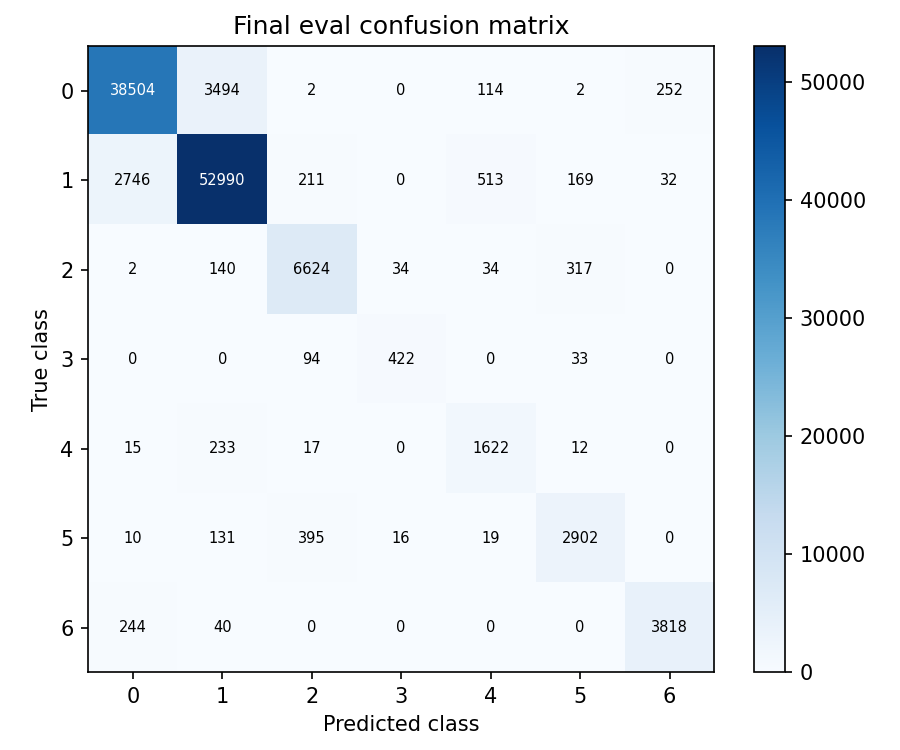

In [9]:
baseline, final = choose_final(all_results, OUT_DIR)
print("Final cfg:", final["cfg"])
scores = finish_submission(all_results, baseline, final, data, REPO_ROOT, OUT_DIR,
                           student_name=STUDENT_NAME, evaluate_eval=MODE == "full")
print("Đã ghi experiments.xlsx và REPORT.md vào", OUT_DIR)
display(Markdown(Path(OUT_DIR, "REPORT.md").read_text(encoding="utf-8")))
if MODE == "full":
    display(__import__("IPython").display.Image(filename=str(Path(OUT_DIR)/"figures/confusion_final.png")))


### Nhận xét Part 4 sau khi chạy
Final được chọn từ validation: hparam-wide, seed 1, epoch 20. Evaluator gốc: macro-F1=0.876284, accuracy=0.919787; baseline 0.842746/0.904340. Lớp 4 khó nhất (F1=0.7722); recall tăng nhưng precision giảm và có 513 mẫu lớp 1 bị dự đoán thành lớp 4. Chỉ hai CSV baseline/final được chấm; không dùng eval để chọn cấu hình.

### Hoàn tất nộp bài
Notebook này đã được tải từ Colab kèm output. Báo cáo và bảng được hoàn thiện từ kết quả đã chạy; gói nộp được tạo lại tại máy local. Không cần chạy lại các cell để sử dụng gói nộp đã kiểm tra.

In [10]:
if MODE == "full":
    submission_zip = package_submission(OUT_DIR)
    print("ZIP:", submission_zip)
    from IPython.display import FileLink
    display(FileLink(submission_zip))
    # Colab: bỏ comment để tải ZIP artifact
    # from google.colab import files
    # files.download(submission_zip)
else:
    print("Smoke đã hoàn tất; chuyển MODE='full' và bật GPU để chạy kết quả nộp.")


ZIP: /content/drive/MyDrive/K4_Track4_Day1/submission_2A202602625.zip


/content/drive/MyDrive/K4_Track4_Day1/submission_2A202602625.zip